In [ ]:
from amoc_analysis import data, plotting
import amocatlas
from spectra_filtering import analysis, data_io, filters, leakage, spectra
from amocatlas import read 

In [226]:
from scipy import signal
from scipy.stats import chi2
import matplotlib.pyplot as plt
import numpy as np 

In [212]:
import importlib 
importlib.reload(spectra)

<module 'spectra_filtering.spectra' from 'C:\\Users\\Isabelle\\Documents\\GitHub\\data_analysis-assignment\\spectra_filtering\\spectra.py'>

## Read OSNAP data

In [213]:
ds = read.osnap()

Loading 1 OSNAP dataset(s):
  0. OSNAP_MOC_MHT_MFT_TimeSeries_201408_202207_2025.nc: Time series of MOC, MHT, and MFT (2014-2022)



## Explore stats

In [214]:
moc = ds['MOC_EAST_SIGMA0']

In [215]:
analysis.summary_stats(moc)

{'n': 96,
 'n_missing': <xarray.DataArray 'MOC_EAST_SIGMA0' ()> Size: 8B
 array(0)
 Attributes:
     long_name:         Eastern MOC_sigma0
     units:             Sverdrup
     QC_indicatoris:    good data
     processing_level:  data manually reviewed
     comment:           maximum of the overturning streamfunction in sigma_the...
     description:       Maximum overturning streamfunction across OSNAP East
     standard_name:     ocean_meridional_overturning_streamfunction,
 'mean': np.float64(16.351453296346662),
 'std': np.float64(2.907178078280368),
 'median': np.float64(16.191231819090753),
 'min': np.float64(10.359161634530988),
 'max': np.float64(23.658947304273145),
 'range': np.float64(13.299785669742157)}

- discovered this function after i did all of this manually for the `osnap_characteristics.ipynb`
- shows the general structure of the dataset 
- here the dataset is again OSNAP EAST MOC

### define spectra values

In [216]:
x = moc.interpolate_na("TIME").values
fs = 1/30
series_raw = np.asarray(x)
series = series_raw[np.isfinite(series_raw)]
time_years = np.arange(series_raw.size) / fs / 365.25

- we interpolate the time variable to not have any gaps 
- here we don't have any gaps to start with so this is a little bit of an uneccessary step, but if this code would be used for a dataset which does have gaps then this step is essential (because this analysis only works with a continuous time variable)

### calculate periodogram and welch 

In [217]:
periodogram = spectra.raw_periodogram(
    series,
    dt_days=30,
    detrend='linear',
)
f_p_spectra = periodogram[0]
Pxx_p_spectra = periodogram[1]

- here we calculate the periodogram with the function defined in the `spectra.py`module 
- then i define the periodogram spectra values and the power spectral density from the dictionary returned by the function
- the function defaults to a 'boxcar' window

In [218]:
# define segment length and overlap for Welch's method
nperseg = min(96, series.size)
overlap = max(0, nperseg // 2)

- now we define the segment length 
- as we have monthly data the segment length cannot be so long (as in the RAPID example)
- therefore our length is 96 
- then naturally our overlap is half as much, so 48


In [219]:
# welch from spectra.py module
# here defining no overlap results in using half of the segment length as overlap value
welch_psd = spectra.welch_psd(
    series,
    dt_days=30,
    segment_length=nperseg,
    window='hann',
)

- now we use the function `welch_psd` from `spectra.py` to calculate our welch spectrum 
- we define our window to be 'hann' because of leakage and tapering (is nicer with frequencies, could also do tukey though i think)
- the overlap here defaults to half of the segment_length defined, which is what i wanted - therefore i did not specify it in the function here
- the input dt_days is the sampling frequency which is then used in both the original `signal.periodogram` and `signal.welch` function as `fs = 1/dt_days`.


In [220]:
# extracting values from dictionary returned by welch_psd function
Pxx_w_spectra = welch_psd['psd']
f_w_spectra = welch_psd['freq']
hi_w = welch_psd['hi']
lo_w = welch_psd['lo']

### define comparsion values for parseval

In [221]:
# parseval ratio
ratio = spectra.parseval_ratio(series, f_w_spectra, Pxx_w_spectra)
ratio

0.739160272145596

- here the parseval ratio is calculated 
- our magical way of seeing if iour calcualtions/code actually make sense
- it relates the time and frequency domain 
- here it basically says that the variance iof our variable in the time domain is the same as the integral of our psd and frequency in the frequency domain

## define plotting values

In [224]:
# length of frequency steps
df_p = f_p_spectra[1] - f_p_spectra[0] 
df_w = f_w_spectra[1] - f_w_spectra[0]

# variance in time domain
var_time = np.var(series)

# variance in frequency domain
var_p = np.sum(Pxx_p_spectra) * df_p
var_w = np.sum(Pxx_w_spectra) * df_w

# frequency steps in cycles per year
freq_p = f_p_spectra[1:] * 365.25
freq_w = f_w_spectra[1:] * 365.25

# power spectral density values for plotting (excluding the zero frequency component)
Pxx_p_plot = Pxx_p_spectra[1:]
Pxx_w_plot = Pxx_w_spectra[1:]

# confidence intervals for Welch's method
segments = max(1, 1 + max(0, series.size - nperseg) // max(1, nperseg - overlap))
dof = 2 * segments
lo = dof / chi2.ppf(0.975, dof)
hi = dof / chi2.ppf(0.025, dof)

### plot spectrum

OSNAP variance: time domain = 8.3636, periodogram = 8.3387, Welch = 6.2094, parseval ratio = 0.7392


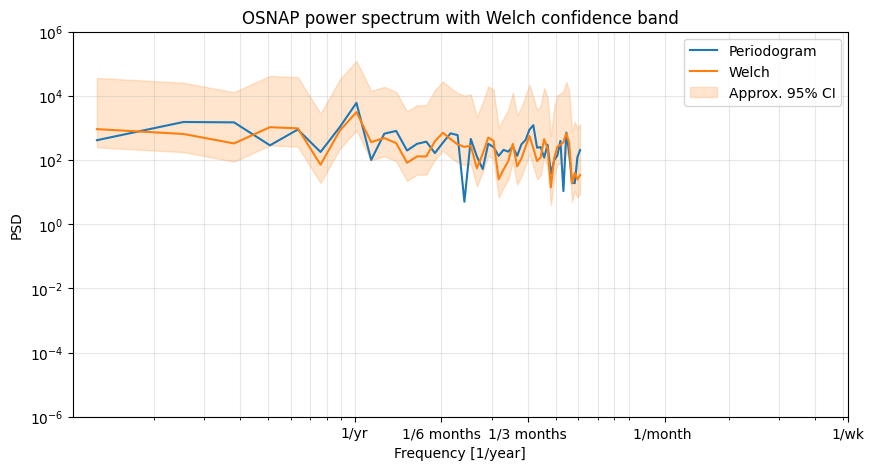

In [225]:
fig, ax = plt.subplots(figsize=(10, 5))

# plot periodogram
ax.loglog(freq_p, Pxx_p_plot, label='Periodogram')

# plot Welch's method with confidence intervals
ax.loglog(freq_w, Pxx_w_plot, label='Welch')
ax.fill_between(
    freq_w,
    Pxx_w_plot * lo,
    Pxx_w_plot * hi,
    color='C1',
    alpha=0.2,
    label='Approx. 95% CI',
)

# adjust plotting parameters
ax.set_title('OSNAP power spectrum with Welch confidence band')
ax.set_xlabel('Frequency [1/year]')
ax.set_ylabel('PSD')
axis_max = max(float(np.nanmax(freq_p)), float(np.nanmax(freq_w)))
ax.set_xticks([1,2, 4, 12, 52])
ax.set_xticklabels(['1/yr', '1/6 months', '1/3 months', '1/month ', '1/wk'])
ax.grid(True, which='both', alpha=0.3)
ax.legend()
ax.set_ylim(1e-6, 1e6)

# print check of variance values (parseval)
print(f'OSNAP variance: time domain = {var_time:.4f}, periodogram = {var_p:.4f}, Welch = {var_w:.4f}, parseval ratio = {ratio:.4f}')

- weirdly there is no rolloff 
- we do see the increased peak for the annual variability
- an another smaller peak for 3 monthly variability
- is there no rolloff because we do not have any signals lower than a month (because of the resolution)?